# GridLock — verify candidate endpoint coordinates

This notebook takes the candidate coordinates we got for unresolved Dominion / former SCE&G assets and checks them against public infrastructure data.

The coordinates in the registry below are treated as **candidates**, not truth.

The notebook verifies each point using:

1. **HIFLD substations** — nearest public substation point, name, voltage, operator if available.
2. **OpenStreetMap / Overpass cache** — nearest named `power=substation` / switching feature.
3. **Cached DOE/HIFLD transmission lines** — nearest same-voltage public line geometry.
4. **Project context** — the voltage(s) and names already present in `dominion_asset_review.csv`.

It does **not** invent a coordinate if evidence is weak.

Output status meanings:

- `verified` → strong public-map support
- `likely` → location is plausible but one check is missing or ambiguous
- `needs_review` → the candidate point is not supported well enough


## 1. Imports and your project paths

This uses the path constants you already keep under `src/gridlock`.

If your path constants live somewhere else, only change this import cell.

In [2]:
from pathlib import Path
from collections import defaultdict
from difflib import SequenceMatcher
import json
import math
import re
import time

import pandas as pd
import requests

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

from gridlock.paths import (
    PROJECT_ROOT,
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    DOCS_DIR,
    NOTEBOOKS_DIR,
)

REVIEW_CSV = PROCESSED_DATA_DIR / "geo/dominion_asset_review.csv"

PUBLIC_GIS_ROOT = RAW_DATA_DIR / "public_gis"
OSM_ROOT = RAW_DATA_DIR / "osm"

OUTPUT_CSV = PROCESSED_DATA_DIR / "geo/endpoint_verification_registry.csv"
OUTPUT_GEOJSON = PROCESSED_DATA_DIR / "geo/endpoint_verification_registry.geojson"

print("Project root:", PROJECT_ROOT)
print("Review CSV:", REVIEW_CSV)
print("Output CSV:", OUTPUT_CSV)


Project root: C:\Users\sebas\PycharmProjects\Git\Project_secret_project
Review CSV: C:\Users\sebas\PycharmProjects\Git\Project_secret_project\data\processed\geo\dominion_asset_review.csv
Output CSV: C:\Users\sebas\PycharmProjects\Git\Project_secret_project\data\processed\geo\endpoint_verification_registry.csv


## 2. Candidate endpoint registry

These are the candidate coordinates supplied by Gemini.

Important: Gemini did **not** provide a source tied to each individual coordinate, so `candidate_source` is intentionally recorded as:

```text
Gemini candidate — exact source not supplied
```

The purpose of this notebook is to independently check them.

In [4]:
candidate_rows = [
    ("VCS1", "Virgil C. Summer Nuclear Station / Unit 1 area", 34.2954, -81.3211),
    ("VCS2", "Virgil C. Summer Nuclear Station / Unit 2 area", 34.2954, -81.3211),
    ("Graniteville", "Graniteville 230 kV Substation", 33.5714, -81.8219),
    ("Bush River", "Bush River 115 kV Substation", 34.1950, -81.6560),
    ("Modoc", "Modoc 115 kV Substation", 33.7225, -82.2081),
    ("Lyles", "Lyles 115 kV Substation", 34.0203, -81.0544),
    ("Kilbourne Park", "Kilbourne Park Substation", 33.9984, -80.9856),
    ("Killian", "Killian 230/115 kV Substation", 34.1432, -80.9634),
    ("Ritter", "Ritter 230 kV Substation", 32.7842, -80.6215),
    ("Long Savannah", "Long Savannah Substation", 32.8122, -80.1255),
    ("Bayfront", "Bayfront 115 kV Substation", 32.7486, -79.9575),
    ("Camp Road", "Camp Road 115 kV Substation", 32.7303, -79.9412),
    ("Dawson", "Dawson 230 kV Substation", 33.0039, -80.1795),
    ("Belv Sw Sta", "Belvedere Switching Station", 33.5350, -81.9392),
    ("Faber Place", "Faber Place Substation", 32.8402, -79.9535),
    ("Hooks", "Hooks 115 kV Substation", 33.6436, -81.9808),
    ("St Helena", "St. Helena Substation", 32.3785, -80.5642),
    ("Hopkins", "Hopkins 230 kV Substation", 33.9108, -80.8252),
    ("Richland Mall GOAB", "Richland Mall GOAB / air-break switch location", 34.0049, -80.9950),
    ("Winnsboro", "Winnsboro 115 kV Substation", 34.3644, -81.1011),
    ("Okatie", "Okatie 115 kV Substation", 32.3275, -80.9320),
    ("McIntosh", "McIntosh Substation / Georgia tie", 32.3164, -81.1394),
    ("Mateeba", "Mateeba Substation", 32.9610, -80.1472),
    ("Ravenel", "Ravenel Substation", 32.7781, -80.2458),
    ("Eastover", "Eastover Substation", 33.8821, -80.7022),
    ("Ashley River", "Ashley River Substation", 32.8550, -80.0881),
    ("James Island", "James Island 115 kV Substation", 32.7470, -79.9431),
    ("Boone Hill", "Boone Hill Substation", 33.0019, -80.2114),
]

candidates = pd.DataFrame(
    candidate_rows,
    columns=[
        "endpoint_name",
        "candidate_resolved_name",
        "candidate_latitude",
        "candidate_longitude",
    ],
)

candidates["candidate_source"] = "candidate"
candidates["candidate_status"] = "unverified"

print("Candidate endpoints:", len(candidates))
display(candidates)


Candidate endpoints: 28


,endpoint_name,candidate_resolved_name,candidate_latitude,candidate_longitude,candidate_source,candidate_status
0,VCS1,Virgil C. Summer Nuclear Station / Unit 1 area,34.2954,-81.3211,candidate,unverified
1,VCS2,Virgil C. Summer Nuclear Station / Unit 2 area,34.2954,-81.3211,candidate,unverified
2,Graniteville,Graniteville 230 kV Substation,33.5714,-81.8219,candidate,unverified
3,Bush River,Bush River 115 kV Substation,34.1950,-81.6560,candidate,unverified
4,Modoc,Modoc 115 kV Substation,33.7225,-82.2081,candidate,unverified
5,Lyles,Lyles 115 kV Substation,34.0203,-81.0544,candidate,unverified
6,Kilbourne Park,Kilbourne Park Substation,33.9984,-80.9856,candidate,unverified
7,Killian,Killian 230/115 kV Substation,34.1432,-80.9634,candidate,unverified
8,Ritter,Ritter 230 kV Substation,32.7842,-80.6215,candidate,unverified
9,Long Savannah,Long Savannah Substation,32.8122,-80.1255,candidate,unverified


## 3. Pull project context from `dominion_asset_review.csv`

This tells us which voltages each endpoint appears with in the actual SCRTP/Dominion project data.

Example:

```text
Hopkins → 230 kV
Bush River → 115 kV
Ritter → 230 kV
```

If an endpoint appears at multiple voltages, all are retained.

In [5]:
if not REVIEW_CSV.exists():
    raise FileNotFoundError(
        f"{REVIEW_CSV} does not exist. "
        "Place dominion_asset_review.csv in data/processed or change REVIEW_CSV."
    )

review = pd.read_csv(REVIEW_CSV)


def normalize_name(value):
    if value is None or pd.isna(value):
        return ""

    value = str(value).lower()
    value = value.replace("&", " and ")
    value = value.replace("–", "-").replace("—", "-")

    replacements = {
        r"\bst[.]?\b": "saint",
        r"\bjct\b": "junction",
        r"\bsw\s+sta\b": "switching station",
        r"\bsta\b": "station",
        r"\bsub\b": "substation",
    }

    for pattern, repl in replacements.items():
        value = re.sub(pattern, repl, value)

    value = re.sub(r"[^a-z0-9#]+", " ", value)
    return re.sub(r"\s+", " ", value).strip()


def parse_voltage(value):
    if value is None or pd.isna(value):
        return None

    values = re.findall(r"\d+(?:\.\d+)?", str(value))

    if not values:
        return None

    return float(values[0])


endpoint_voltage_map = defaultdict(set)

for _, row in review.iterrows():
    voltage = parse_voltage(row.get("voltage_kv"))

    for column in ("endpoint_a", "endpoint_b"):
        endpoint = row.get(column)

        if endpoint is None or pd.isna(endpoint) or not str(endpoint).strip():
            continue

        if voltage is not None:
            endpoint_voltage_map[normalize_name(endpoint)].add(voltage)


def project_voltages_for(endpoint_name):
    values = sorted(endpoint_voltage_map.get(normalize_name(endpoint_name), set()))
    return values


candidates["project_voltages_kv"] = candidates["endpoint_name"].apply(project_voltages_for)

display(
    candidates[
        [
            "endpoint_name",
            "candidate_resolved_name",
            "project_voltages_kv",
        ]
    ]
)


,endpoint_name,candidate_resolved_name,project_voltages_kv
0,VCS1,Virgil C. Summer Nuclear Station / Unit 1 area,[230.0]
1,VCS2,Virgil C. Summer Nuclear Station / Unit 2 area,[230.0]
2,Graniteville,Graniteville 230 kV Substation,[115.0]
3,Bush River,Bush River 115 kV Substation,[115.0]
4,Modoc,Modoc 115 kV Substation,"[46.0, 115.0]"
5,Lyles,Lyles 115 kV Substation,[115.0]
6,Kilbourne Park,Kilbourne Park Substation,[115.0]
7,Killian,Killian 230/115 kV Substation,[230.0]
8,Ritter,Ritter 230 kV Substation,"[115.0, 230.0]"
9,Long Savannah,Long Savannah Substation,[230.0]


## 4. Name-matching helpers

We use:

1. exact normalized name,
2. containment,
3. small typo tolerance.

The typo step is only there for small public-map spelling differences such as:

```text
Urquhart
Uruquart
```

It is not an AI confidence model.

In [6]:
GENERIC_WORDS = {
    "substation",
    "station",
    "switching",
    "switchyard",
    "transmission",
    "plant",
    "hydro",
    "facility",
    "tap",
    "junction",
    "line",
}


def core_name(value):
    tokens = normalize_name(value).split()

    while tokens and tokens[-1] in GENERIC_WORDS:
        tokens.pop()

    return " ".join(tokens)


def name_match_kind(a, b):
    a_core = core_name(a)
    b_core = core_name(b)

    if not a_core or not b_core:
        return None

    if a_core == b_core:
        return "exact"

    if len(a_core) >= 5 and a_core in b_core:
        return "contains"

    if len(b_core) >= 5 and b_core in a_core:
        return "contains"

    if min(len(a_core), len(b_core)) >= 6:
        ratio = SequenceMatcher(None, a_core, b_core).ratio()

        if ratio >= 0.82:
            return "typo"

    return None


## 5. Distance and geometry helpers

These are simple geographic calculations used to measure:

- candidate point → public substation point
- candidate point → nearest same-voltage transmission line vertex

For this verification step, nearest-vertex distance is good enough to flag whether the candidate is sitting on the expected infrastructure corridor.

In [7]:
def haversine_km(lon1, lat1, lon2, lat2):
    radius_km = 6371.0088

    lon1, lat1, lon2, lat2 = map(
        math.radians,
        [lon1, lat1, lon2, lat2],
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1)
        * math.cos(lat2)
        * math.sin(dlon / 2) ** 2
    )

    return 2 * radius_km * math.asin(math.sqrt(a))


def geometry_parts(geometry):
    if not geometry:
        return []

    geom_type = geometry.get("type")
    coords = geometry.get("coordinates") or []

    if geom_type == "LineString":
        return [coords]

    if geom_type == "MultiLineString":
        return coords

    if "paths" in geometry:
        return geometry["paths"]

    return []


def point_to_line_vertices_km(lon, lat, geometry):
    distances = []

    for part in geometry_parts(geometry):
        for point in part:
            distances.append(
                haversine_km(
                    lon,
                    lat,
                    point[0],
                    point[1],
                )
            )

    return min(distances) if distances else float("inf")


## 6. Load cached DOE/HIFLD transmission lines

This reuses the line chunks Codex already downloaded under:

```text
data/raw/public_gis/<STATE>/netl_lines_*.json
```

No new transmission-line download is needed.

In [8]:
def lower_keys(mapping):
    return {
        str(key).lower(): value
        for key, value in (mapping or {}).items()
    }


def arcgis_geometry_to_geojson(geometry):
    if not geometry:
        return None

    if "type" in geometry and "coordinates" in geometry:
        return geometry

    paths = geometry.get("paths")

    if not paths:
        return None

    if len(paths) == 1:
        return {
            "type": "LineString",
            "coordinates": paths[0],
        }

    return {
        "type": "MultiLineString",
        "coordinates": paths,
    }


def load_line_file(path):
    data = json.loads(path.read_text(encoding="utf-8"))

    if isinstance(data, dict):
        features = data.get("features", [])
    elif isinstance(data, list):
        features = data
    else:
        features = []

    rows = []

    for feature in features:
        attrs = lower_keys(
            feature.get("properties")
            or feature.get("attributes")
            or {}
        )

        geometry = arcgis_geometry_to_geojson(feature.get("geometry"))

        if not geometry:
            continue

        voltage = attrs.get("voltage")

        try:
            voltage = float(voltage)
        except (TypeError, ValueError):
            voltage = None

        if voltage is not None and voltage < 0:
            voltage = None

        rows.append({
            "feature_id": (
                attrs.get("id")
                or attrs.get("objectid")
                or attrs.get("objectid_1")
                or feature.get("id")
            ),
            "owner": attrs.get("owner"),
            "sub_1": attrs.get("sub_1"),
            "sub_2": attrs.get("sub_2"),
            "voltage": voltage,
            "geometry": geometry,
            "source_file": str(path),
        })

    return rows


line_files = sorted(PUBLIC_GIS_ROOT.glob("*/netl_lines_*.json"))

if not line_files:
    raise FileNotFoundError(
        f"No netl_lines_*.json files found under {PUBLIC_GIS_ROOT}"
    )

line_rows = []

for path in line_files:
    loaded = load_line_file(path)
    line_rows.extend(loaded)
    print(path.relative_to(PROJECT_ROOT), "->", len(loaded))

lines = pd.DataFrame(line_rows)

lines["_dedupe"] = (
    lines["feature_id"].astype(str)
    + "|"
    + lines["voltage"].astype(str)
)

lines = (
    lines
    .drop_duplicates("_dedupe")
    .drop(columns="_dedupe")
    .reset_index(drop=True)
)

print("Unique cached line features:", len(lines))


data\raw\public_gis\SC\netl_lines_0.json -> 2000
data\raw\public_gis\SC\netl_lines_2000.json -> 2000
data\raw\public_gis\SC\netl_lines_4000.json -> 793
Unique cached line features: 3657


## 7. Load statewide OSM substations if the cache already exists

The route resolver already used files like:

```text
data/raw/osm/SC/power_substations_overpass.json
```

If those files exist, this notebook reuses them.

If not, the OSM check will simply remain blank rather than failing the whole notebook.

In [9]:
def overpass_element_point(element):
    if "lat" in element and "lon" in element:
        return float(element["lon"]), float(element["lat"])

    center = element.get("center")

    if center:
        return float(center["lon"]), float(center["lat"])

    geometry = element.get("geometry")

    if geometry:
        points = [
            (float(p["lon"]), float(p["lat"]))
            for p in geometry
            if "lon" in p and "lat" in p
        ]

        if points:
            lon = sum(p[0] for p in points) / len(points)
            lat = sum(p[1] for p in points) / len(points)
            return lon, lat

    return None


osm_rows = []

for state_dir in sorted(OSM_ROOT.glob("*")):
    if not state_dir.is_dir():
        continue

    path = state_dir / "power_substations_overpass.json"

    if not path.exists():
        continue

    state = state_dir.name.upper()
    data = json.loads(path.read_text(encoding="utf-8"))

    for element in data.get("elements", []):
        tags = element.get("tags") or {}
        name = tags.get("name")

        if not name:
            continue

        point = overpass_element_point(element)

        if not point:
            continue

        osm_rows.append({
            "state": state,
            "feature_id": f"{element.get('type')}/{element.get('id')}",
            "name": name,
            "operator": tags.get("operator"),
            "voltage": tags.get("voltage"),
            "lon": point[0],
            "lat": point[1],
        })

osm_stations = pd.DataFrame(osm_rows)

print("Cached named OSM station features:", len(osm_stations))


Cached named OSM station features: 439


## 8. Download HIFLD substation points once

This is the only fresh public-data request in the notebook.

The ArcGIS service returns the public HIFLD substation point layer. We download South Carolina and Georgia because the Dominion project set includes cross-border ties.

The result is cached locally so later notebook runs do not redownload it.

In [10]:
HIFLD_SUBSTATIONS_QUERY = (
    "https://services.arcgis.com/HQ0xoN0EzDPBOEci/"
    "ArcGIS/rest/services/Substations/FeatureServer/0/query"
)

CACHE_DIR = RAW_DATA_DIR / "public_gis" / "verification_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

session = requests.Session()
session.headers.update(
    {
        "User-Agent": "GridLock-Hackathon-Endpoint-Verification/0.1"
    }
)


def fetch_hifld_state(state):
    cache_path = CACHE_DIR / f"hifld_substations_{state}.geojson"

    if cache_path.exists():
        return json.loads(cache_path.read_text(encoding="utf-8"))

    all_features = []
    offset = 0
    page_size = 2000

    while True:
        params = {
            "where": f"STATE = '{state}'",
            "outFields": "*",
            "returnGeometry": "true",
            "outSR": 4326,
            "f": "geojson",
            "resultOffset": offset,
            "resultRecordCount": page_size,
        }

        response = session.get(
            HIFLD_SUBSTATIONS_QUERY,
            params=params,
            timeout=120,
        )
        response.raise_for_status()

        data = response.json()
        batch = data.get("features", [])

        all_features.extend(batch)

        if len(batch) < page_size:
            break

        offset += len(batch)
        time.sleep(0.2)

    result = {
        "type": "FeatureCollection",
        "features": all_features,
    }

    cache_path.write_text(
        json.dumps(result),
        encoding="utf-8",
    )

    return result


hifld_rows = []

for state in ["SC", "GA"]:
    fc = fetch_hifld_state(state)
    print(state, "HIFLD substations:", len(fc.get("features", [])))

    for feature in fc.get("features", []):
        props = lower_keys(feature.get("properties") or {})
        geometry = feature.get("geometry") or {}

        if geometry.get("type") != "Point":
            continue

        coords = geometry.get("coordinates") or []

        if len(coords) < 2:
            continue

        hifld_rows.append({
            "state": state,
            "feature_id": (
                props.get("id")
                or props.get("objectid")
                or props.get("fid")
            ),
            "name": props.get("name"),
            "type": props.get("type"),
            "min_voltage": props.get("min_volt"),
            "max_voltage": props.get("max_volt"),
            "city": props.get("city"),
            "county": props.get("county"),
            "lon": float(coords[0]),
            "lat": float(coords[1]),
        })

hifld_substations = pd.DataFrame(hifld_rows)

print("Total HIFLD substation points:", len(hifld_substations))


SC HIFLD substations: 2476
GA HIFLD substations: 2501
Total HIFLD substation points: 4977


## 9. Find the nearest HIFLD and OSM station to each candidate

For each candidate coordinate we record:

- nearest station distance
- nearest station name
- whether the name agrees with our endpoint name
- voltage compatibility when HIFLD provides it

This makes the evidence inspectable instead of hiding it behind one score.

In [11]:
def nearest_station_match(candidate_row, stations, source_name):
    lon = candidate_row["candidate_longitude"]
    lat = candidate_row["candidate_latitude"]

    if stations.empty:
        return {
            f"{source_name}_nearest_name": None,
            f"{source_name}_nearest_distance_km": None,
            f"{source_name}_name_match": None,
            f"{source_name}_feature_id": None,
        }

    working = stations.copy()

    working["_distance_km"] = working.apply(
        lambda row: haversine_km(
            lon,
            lat,
            row["lon"],
            row["lat"],
        ),
        axis=1,
    )

    nearest = working.nsmallest(10, "_distance_km").copy()

    endpoint_name = candidate_row["endpoint_name"]
    resolved_name = candidate_row["candidate_resolved_name"]

    nearest["_match_kind"] = nearest["name"].apply(
        lambda name: (
            name_match_kind(endpoint_name, name)
            or name_match_kind(resolved_name, name)
        )
    )

    named_matches = nearest[nearest["_match_kind"].notna()]

    chosen = (
        named_matches.iloc[0]
        if not named_matches.empty
        else nearest.iloc[0]
    )

    result = {
        f"{source_name}_nearest_name": chosen.get("name"),
        f"{source_name}_nearest_distance_km": chosen.get("_distance_km"),
        f"{source_name}_name_match": chosen.get("_match_kind"),
        f"{source_name}_feature_id": chosen.get("feature_id"),
    }

    if source_name == "hifld":
        result["hifld_min_voltage"] = chosen.get("min_voltage")
        result["hifld_max_voltage"] = chosen.get("max_voltage")
        result["hifld_city"] = chosen.get("city")
        result["hifld_county"] = chosen.get("county")

    if source_name == "osm":
        result["osm_operator"] = chosen.get("operator")
        result["osm_voltage"] = chosen.get("voltage")

    return result


verification_rows = []

for _, candidate in candidates.iterrows():
    row = candidate.to_dict()

    row.update(
        nearest_station_match(
            candidate,
            hifld_substations,
            "hifld",
        )
    )

    row.update(
        nearest_station_match(
            candidate,
            osm_stations,
            "osm",
        )
    )

    verification_rows.append(row)

verification = pd.DataFrame(verification_rows)

display(
    verification[
        [
            "endpoint_name",
            "candidate_latitude",
            "candidate_longitude",
            "hifld_nearest_name",
            "hifld_nearest_distance_km",
            "hifld_name_match",
            "osm_nearest_name",
            "osm_nearest_distance_km",
            "osm_name_match",
        ]
    ]
)


,endpoint_name,candidate_latitude,candidate_longitude,hifld_nearest_name,hifld_nearest_distance_km,hifld_name_match,osm_nearest_name,osm_nearest_distance_km,osm_name_match
0,VCS1,34.2954,-81.3211,UNKNOWN117127,0.516447,NaN,Virgil C. Summer Nuclear #1 Substation,0.578572,NaN
1,VCS2,34.2954,-81.3211,UNKNOWN117127,0.516447,NaN,Virgil C. Summer Nuclear #1 Substation,0.578572,NaN
2,Graniteville,33.5714,-81.8219,UNKNOWN117189,2.019565,NaN,Burnettown Substation,6.502018,NaN
3,Bush River,34.1950,-81.6560,TAP154019,5.400423,NaN,International Paper Substation,9.167920,NaN
4,Modoc,33.7225,-82.2081,UNKNOWN116757,1.650477,NaN,Modoc Substation,1.653998,exact
5,Lyles,34.0203,-81.0544,UNKNOWN117533,0.583718,NaN,Network Substation,2.521277,NaN
6,Kilbourne Park,33.9984,-80.9856,UNKNOWN122466,1.844574,NaN,Rosewood Substation,1.572428,NaN
7,Killian,34.1432,-80.9634,UNKNOWN152700,1.285791,NaN,Langfords Crossroads,9.021342,NaN
8,Ritter,32.7842,-80.6215,UNKNOWN120999,4.341095,NaN,South Walterboro Substation,12.409497,NaN
9,Long Savannah,32.8122,-80.1255,UNKNOWN121003,1.328004,NaN,Church Creek Substation,5.519651,NaN


## 10. Check distance to the nearest same-voltage transmission line

This is the strongest spatial sanity check.

If the project says:

```text
Hopkins 230 kV
```

and the candidate point is sitting hundreds of kilometers from every 230 kV line, something is wrong.

If it is a few hundred meters from a 230 kV public line, that strongly supports the candidate location.

When an endpoint appears at multiple project voltages, the notebook checks all of them and keeps the closest matching-voltage result.

In [12]:
def nearest_matching_voltage_line(candidate_row):
    lon = candidate_row["candidate_longitude"]
    lat = candidate_row["candidate_latitude"]

    requested_voltages = candidate_row["project_voltages_kv"]

    if not requested_voltages:
        return {
            "nearest_project_voltage_line_km": None,
            "nearest_project_voltage_line_kv": None,
            "nearest_line_feature_id": None,
            "nearest_line_owner": None,
            "nearest_line_sub_1": None,
            "nearest_line_sub_2": None,
        }

    best = None

    for voltage in requested_voltages:
        subset = lines[
            lines["voltage"].notna()
            & lines["voltage"].sub(voltage).abs().lt(0.5)
        ]

        for _, line in subset.iterrows():
            distance = point_to_line_vertices_km(
                lon,
                lat,
                line["geometry"],
            )

            candidate = {
                "distance": distance,
                "voltage": voltage,
                "feature_id": line["feature_id"],
                "owner": line["owner"],
                "sub_1": line["sub_1"],
                "sub_2": line["sub_2"],
            }

            if best is None or distance < best["distance"]:
                best = candidate

    if best is None:
        return {
            "nearest_project_voltage_line_km": None,
            "nearest_project_voltage_line_kv": None,
            "nearest_line_feature_id": None,
            "nearest_line_owner": None,
            "nearest_line_sub_1": None,
            "nearest_line_sub_2": None,
        }

    return {
        "nearest_project_voltage_line_km": best["distance"],
        "nearest_project_voltage_line_kv": best["voltage"],
        "nearest_line_feature_id": best["feature_id"],
        "nearest_line_owner": best["owner"],
        "nearest_line_sub_1": best["sub_1"],
        "nearest_line_sub_2": best["sub_2"],
    }


line_checks = verification.apply(
    nearest_matching_voltage_line,
    axis=1,
    result_type="expand",
)

verification = pd.concat(
    [
        verification.reset_index(drop=True),
        line_checks.reset_index(drop=True),
    ],
    axis=1,
)

display(
    verification[
        [
            "endpoint_name",
            "project_voltages_kv",
            "nearest_project_voltage_line_km",
            "nearest_project_voltage_line_kv",
            "nearest_line_owner",
            "nearest_line_sub_1",
            "nearest_line_sub_2",
        ]
    ]
)


,endpoint_name,project_voltages_kv,nearest_project_voltage_line_km,nearest_project_voltage_line_kv,nearest_line_owner,nearest_line_sub_1,nearest_line_sub_2
0,VCS1,[230.0],0.098323,230.0,NOT AVAILABLE,V C SUMMER,UNKNOWN152556
1,VCS2,[230.0],0.098323,230.0,NOT AVAILABLE,V C SUMMER,UNKNOWN152556
2,Graniteville,[115.0],1.157517,115.0,SOUTH CAROLINA ELECTRIC&GAS CO,UNKNOWN117189,TAP141843
3,Bush River,[115.0],6.424195,115.0,NOT AVAILABLE,UNKNOWN116988,UNKNOWN152557
4,Modoc,"[46.0, 115.0]",1.330641,115.0,SOUTH CAROLINA ELECTRIC&GAS CO,STEVENS CREEK,TAP141829
5,Lyles,[115.0],0.086512,115.0,SOUTH CAROLINA ELECTRIC&GAS COMPANY,UNKNOWN117533,TAP160554
6,Kilbourne Park,[115.0],1.670950,115.0,SOUTH CAROLINA ELECTRIC&GAS COMPANY,UNKNOWN122466,TAP152684
7,Killian,[230.0],0.943706,230.0,SOUTH CAROLINA ELECTRIC&GAS COMPANY,V C SUMMER,UNKNOWN117539
8,Ritter,"[115.0, 230.0]",2.763894,230.0,SOUTH CAROLINA ELECTRIC&GAS CO,UNKNOWN120999,YEMASSEE
9,Long Savannah,[230.0],0.285077,230.0,SOUTH CAROLINA ELECTRIC&GAS CO,UNKNOWN120998,UNKNOWN120999


## 11. Transparent verification rules

No hidden score.

A candidate becomes `verified` when at least one public station source agrees strongly **and** the point is spatially consistent with the expected transmission network.

Rules:

### `verified`
At least one of:

- HIFLD name match within 2 km
- OSM name match within 2 km

AND either:

- nearest same-voltage line is within 2 km
- or no project voltage was available to check

### `likely`
No strong station-name match, but:

- nearest same-voltage line is within 1 km

OR:

- nearest HIFLD/OSM station is within 1 km

### `needs_review`
Anything weaker than that.

You can adjust the thresholds later, but they are explicit and easy to inspect.

In [13]:
def classify_verification(row):
    hifld_named_close = (
        pd.notna(row.get("hifld_name_match"))
        and pd.notna(row.get("hifld_nearest_distance_km"))
        and row["hifld_nearest_distance_km"] <= 2.0
    )

    osm_named_close = (
        pd.notna(row.get("osm_name_match"))
        and pd.notna(row.get("osm_nearest_distance_km"))
        and row["osm_nearest_distance_km"] <= 2.0
    )

    same_voltage_line_close = (
        pd.notna(row.get("nearest_project_voltage_line_km"))
        and row["nearest_project_voltage_line_km"] <= 2.0
    )

    no_voltage_to_check = not row.get("project_voltages_kv")

    if (
        (hifld_named_close or osm_named_close)
        and (same_voltage_line_close or no_voltage_to_check)
    ):
        return "verified"

    station_close = (
        (
            pd.notna(row.get("hifld_nearest_distance_km"))
            and row["hifld_nearest_distance_km"] <= 1.0
        )
        or
        (
            pd.notna(row.get("osm_nearest_distance_km"))
            and row["osm_nearest_distance_km"] <= 1.0
        )
    )

    very_close_voltage_line = (
        pd.notna(row.get("nearest_project_voltage_line_km"))
        and row["nearest_project_voltage_line_km"] <= 1.0
    )

    if station_close or very_close_voltage_line:
        return "likely"

    return "needs_review"


verification["verification_status"] = verification.apply(
    classify_verification,
    axis=1,
)

display(
    verification["verification_status"]
    .value_counts()
    .to_frame("endpoints")
)


,endpoints
verification_status,
needs_review,17
likely,10
verified,1


## 12. Build a concise verification note

This makes the CSV human-readable.

Example:

```text
OSM exact-name substation 0.18 km away; nearest 230 kV public line 0.09 km away.
```


In [14]:
def verification_note(row):
    parts = []

    if pd.notna(row.get("hifld_nearest_name")):
        match = row.get("hifld_name_match") or "no-name-match"

        parts.append(
            f"HIFLD: {row['hifld_nearest_name']} "
            f"({match}, {row['hifld_nearest_distance_km']:.2f} km)"
        )

    if pd.notna(row.get("osm_nearest_name")):
        match = row.get("osm_name_match") or "no-name-match"

        parts.append(
            f"OSM: {row['osm_nearest_name']} "
            f"({match}, {row['osm_nearest_distance_km']:.2f} km)"
        )

    if pd.notna(row.get("nearest_project_voltage_line_km")):
        parts.append(
            f"nearest {row['nearest_project_voltage_line_kv']:g} kV line "
            f"{row['nearest_project_voltage_line_km']:.2f} km away"
        )

    return "; ".join(parts)


verification["verification_note"] = verification.apply(
    verification_note,
    axis=1,
)

display(
    verification[
        [
            "endpoint_name",
            "verification_status",
            "verification_note",
        ]
    ]
)


,endpoint_name,verification_status,verification_note
0,VCS1,likely,"HIFLD: UNKNOWN117127 (nan, 0.52 km); OSM: Virgil C. Summer Nuclear #1 Substation (nan, 0.58 km); nearest 230 kV line 0.10 km away"
1,VCS2,likely,"HIFLD: UNKNOWN117127 (nan, 0.52 km); OSM: Virgil C. Summer Nuclear #1 Substation (nan, 0.58 km); nearest 230 kV line 0.10 km away"
2,Graniteville,needs_review,"HIFLD: UNKNOWN117189 (nan, 2.02 km); OSM: Burnettown Substation (nan, 6.50 km); nearest 115 kV line 1.16 km away"
3,Bush River,needs_review,"HIFLD: TAP154019 (nan, 5.40 km); OSM: International Paper Substation (nan, 9.17 km); nearest 115 kV line 6.42 km away"
4,Modoc,verified,"HIFLD: UNKNOWN116757 (nan, 1.65 km); OSM: Modoc Substation (exact, 1.65 km); nearest 115 kV line 1.33 km away"
5,Lyles,likely,"HIFLD: UNKNOWN117533 (nan, 0.58 km); OSM: Network Substation (nan, 2.52 km); nearest 115 kV line 0.09 km away"
6,Kilbourne Park,needs_review,"HIFLD: UNKNOWN122466 (nan, 1.84 km); OSM: Rosewood Substation (nan, 1.57 km); nearest 115 kV line 1.67 km away"
7,Killian,likely,"HIFLD: UNKNOWN152700 (nan, 1.29 km); OSM: Langfords Crossroads (nan, 9.02 km); nearest 230 kV line 0.94 km away"
8,Ritter,needs_review,"HIFLD: UNKNOWN120999 (nan, 4.34 km); OSM: South Walterboro Substation (nan, 12.41 km); nearest 230 kV line 2.76 km away"
9,Long Savannah,likely,"HIFLD: UNKNOWN121003 (nan, 1.33 km); OSM: Church Creek Substation (nan, 5.52 km); nearest 230 kV line 0.29 km away"


## 13. Inspect only the weak candidates

These are the endpoints worth manually checking against Dominion project maps, SC PSC records, or another public GIS source.

The notebook has already eliminated the easy ones.

In [15]:
needs_review = verification[
    verification["verification_status"] == "needs_review"
].copy()

display(
    needs_review[
        [
            "endpoint_name",
            "candidate_resolved_name",
            "candidate_latitude",
            "candidate_longitude",
            "project_voltages_kv",
            "hifld_nearest_name",
            "hifld_nearest_distance_km",
            "osm_nearest_name",
            "osm_nearest_distance_km",
            "nearest_project_voltage_line_km",
            "verification_note",
        ]
    ]
)


,endpoint_name,candidate_resolved_name,candidate_latitude,candidate_longitude,project_voltages_kv,hifld_nearest_name,hifld_nearest_distance_km,osm_nearest_name,osm_nearest_distance_km,nearest_project_voltage_line_km,verification_note
2,Graniteville,Graniteville 230 kV Substation,33.5714,-81.8219,[115.0],UNKNOWN117189,2.019565,Burnettown Substation,6.502018,1.157517,"HIFLD: UNKNOWN117189 (nan, 2.02 km); OSM: Burnettown Substation (nan, 6.50 km); nearest 115 kV line 1.16 km away"
3,Bush River,Bush River 115 kV Substation,34.1950,-81.6560,[115.0],TAP154019,5.400423,International Paper Substation,9.167920,6.424195,"HIFLD: TAP154019 (nan, 5.40 km); OSM: International Paper Substation (nan, 9.17 km); nearest 115 kV line 6.42 km away"
6,Kilbourne Park,Kilbourne Park Substation,33.9984,-80.9856,[115.0],UNKNOWN122466,1.844574,Rosewood Substation,1.572428,1.670950,"HIFLD: UNKNOWN122466 (nan, 1.84 km); OSM: Rosewood Substation (nan, 1.57 km); nearest 115 kV line 1.67 km away"
8,Ritter,Ritter 230 kV Substation,32.7842,-80.6215,"[115.0, 230.0]",UNKNOWN120999,4.341095,South Walterboro Substation,12.409497,2.763894,"HIFLD: UNKNOWN120999 (nan, 4.34 km); OSM: South Walterboro Substation (nan, 12.41 km); nearest 230 kV line 2.76 km away"
10,Bayfront,Bayfront 115 kV Substation,32.7486,-79.9575,[115.0],UNKNOWN147150,1.345406,Queensborough Substation,3.015434,1.177472,"HIFLD: UNKNOWN147150 (nan, 1.35 km); OSM: Queensborough Substation (nan, 3.02 km); nearest 115 kV line 1.18 km away"
13,Belv Sw Sta,Belvedere Switching Station,33.5350,-81.9392,[115.0],UNKNOWN117198,2.044593,Clearwater Substation,6.277508,1.275036,"HIFLD: UNKNOWN117198 (nan, 2.04 km); OSM: Clearwater Substation (nan, 6.28 km); nearest 115 kV line 1.28 km away"
16,St Helena,St. Helena Substation,32.3785,-80.5642,[115.0],UNKNOWN162031,2.392291,Frogmore Substation,2.387486,2.091329,"HIFLD: UNKNOWN162031 (nan, 2.39 km); OSM: Frogmore Substation (nan, 2.39 km); nearest 115 kV line 2.09 km away"
17,Hopkins,Hopkins 230 kV Substation,33.9108,-80.8252,[230.0],UNKNOWN122372,3.772974,Devro Substation,14.042929,4.753341,"HIFLD: UNKNOWN122372 (nan, 3.77 km); OSM: Devro Substation (nan, 14.04 km); nearest 230 kV line 4.75 km away"
18,Richland Mall GOAB,Richland Mall GOAB / air-break switch location,34.0049,-80.9950,[115.0],UNKNOWN160696,1.123368,Five Points Substation,1.947162,1.054297,"HIFLD: UNKNOWN160696 (nan, 1.12 km); OSM: Five Points Substation (nan, 1.95 km); nearest 115 kV line 1.05 km away"
20,Okatie,Okatie 115 kV Substation,32.3275,-80.9320,"[115.0, 230.0]",UNKNOWN121158,1.114676,Cherry Point Wastewater Treatment Substation,7.160596,1.073478,"HIFLD: UNKNOWN121158 (nan, 1.11 km); OSM: Cherry Point Wastewater Treatment Substation (nan, 7.16 km); nearest 115 kV line 1.07 km away"


## 14. Preview candidates on a simple scatter plot

This is only a quick sanity check.

It is not the final GridLock map.

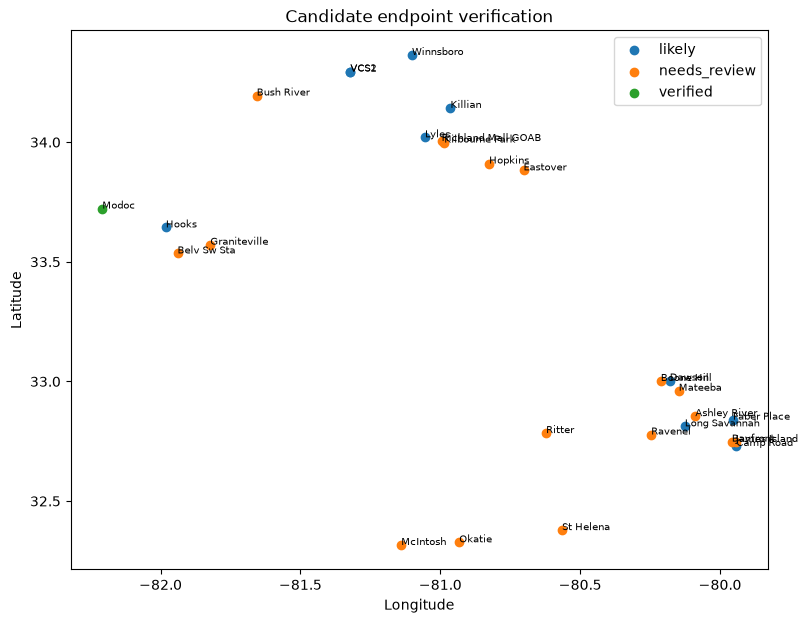

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

for status, group in verification.groupby("verification_status"):
    ax.scatter(
        group["candidate_longitude"],
        group["candidate_latitude"],
        label=status,
    )

for _, row in verification.iterrows():
    ax.annotate(
        row["endpoint_name"],
        (
            row["candidate_longitude"],
            row["candidate_latitude"],
        ),
        fontsize=7,
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Candidate endpoint verification")
ax.legend()
plt.show()


## 15. Save the verified endpoint registry

The CSV is the main result.

The GeoJSON lets you immediately plot the candidate endpoint points in a web map or GIS tool.

In [18]:
verification.to_csv(
    OUTPUT_CSV,
    index=False,
)

features = []

for _, row in verification.iterrows():
    properties = {
        "endpoint_name": row["endpoint_name"],
        "candidate_resolved_name": row["candidate_resolved_name"],
        "candidate_source": row["candidate_source"],
        "project_voltages_kv": json.dumps(row["project_voltages_kv"]),
        "verification_status": row["verification_status"],
        "verification_note": row["verification_note"],
        "hifld_nearest_name": row.get("hifld_nearest_name"),
        "hifld_nearest_distance_km": row.get("hifld_nearest_distance_km"),
        "osm_nearest_name": row.get("osm_nearest_name"),
        "osm_nearest_distance_km": row.get("osm_nearest_distance_km"),
        "nearest_project_voltage_line_km": row.get("nearest_project_voltage_line_km"),
        "nearest_project_voltage_line_kv": row.get("nearest_project_voltage_line_kv"),
        "nearest_line_owner": row.get("nearest_line_owner"),
    }

    for key, value in list(properties.items()):
        if isinstance(value, float) and pd.isna(value):
            properties[key] = None

    features.append({
        "type": "Feature",
        "properties": properties,
        "geometry": {
            "type": "Point",
            "coordinates": [
                row["candidate_longitude"],
                row["candidate_latitude"],
            ],
        },
    })

geojson = {
    "type": "FeatureCollection",
    "features": features,
}

OUTPUT_GEOJSON.write_text(
    json.dumps(geojson),
    encoding="utf-8",
)

print("Saved:")
print(" -", OUTPUT_CSV)
print(" -", OUTPUT_GEOJSON)


Saved:
 - C:\Users\sebas\PycharmProjects\Git\Project_secret_project\data\processed\geo\endpoint_verification_registry.csv
 - C:\Users\sebas\PycharmProjects\Git\Project_secret_project\data\processed\geo\endpoint_verification_registry.geojson


## 16. Feed verified endpoints back into the route resolver

Once you are satisfied with the results:

- `verified` coordinates can become trusted endpoint anchors.
- `likely` coordinates can be used with caution / review.
- `needs_review` should stay unresolved until another public source confirms them.

The next change to the route resolver should be small:

```text
build_endpoint_anchors()
    ↓
check verified endpoint registry first
    ↓
then OSM/HIFLD fallback
```

That way each endpoint is solved once and reused across every project that references it.
